In [1]:
import pandas as pd
import numpy as np
import os
import shutil
import seaborn as sns
from matplotlib import pyplot as plt
from IPython.display import display
INPUT_DIR = './house_price_data'
OUTPUT_DIR = './dataset_raw/house_price_traj/'

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
else:
    shutil.rmtree(OUTPUT_DIR)
    os.makedirs(OUTPUT_DIR)

## Check and clean the survival data

In [2]:
data_median_price_traj = pd.read_csv(os.path.join(INPUT_DIR, 'house-prices-local-authority-time-series-v10.csv'))
data_median_price_traj

,V4_1,Data Marking,calendar-years,Time,mmm,Month,administrative-geography,Geography,property-type,PropertyType,build-status,BuildStatus,house-sales-and-prices,HouseSalesAndPrices
0,3138.0,NaN,2015,2015,sep,September,E08000028,Sandwell,all,All,all,All,sales,Count of sales
1,3578.0,NaN,2018,2018,jun,June,E08000028,Sandwell,all,All,all,All,sales,Count of sales
2,2519.0,NaN,2021,2021,mar,March,E08000028,Sandwell,all,All,all,All,sales,Count of sales
3,269.0,NaN,2015,2015,dec,December,E08000028,Sandwell,flat-maisonette,Flat/maisonette,all,All,sales,Count of sales
4,311.0,NaN,2017,2017,sep,September,E08000028,Sandwell,flat-maisonette,Flat/maisonette,all,All,sales,Count of sales
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794395,NaN,.,2022,2022,dec,December,E06000019,"Herefordshire, County of",detached,Detached,all,All,tenth-percentile,Tenth percentile price
794396,NaN,.,2022,2022,dec,December,E06000019,"Herefordshire, County of",terraced,Terraced,all,All,tenth-percentile,Tenth percentile price
794397,NaN,.,2022,2022,dec,December,E06000019,"Herefordshire, County of",flat-maisonette,Flat/maisonette,newly-built,Newly built,median,Median price
794398,NaN,.,2022,2022,dec,December,E06000019,"Herefordshire, County of",flat-maisonette,Flat/maisonette,newly-built,Newly built,mean,Mean price


In [3]:
median = data_median_price_traj.loc[
     data_median_price_traj['house-sales-and-prices'] == 'median',:
].copy()
sales = data_median_price_traj.loc[
     data_median_price_traj['house-sales-and-prices'] == 'sales',:
].copy()

median = median.rename(columns={'V4_1':'median'}).drop(columns=['house-sales-and-prices', 'HouseSalesAndPrices'])
sales = sales.rename(columns={'V4_1':'sales'}).drop(columns=['house-sales-and-prices', 'HouseSalesAndPrices'])
merged = median.merge(
    sales,
    on=[i for i in median.columns if i in sales.columns],
    how='inner'
)
selector = (merged['median'].notna()) & (merged['sales'].notna())
merged = merged.loc[selector,:]

In [4]:
n_sales_per_year = merged.groupby(['administrative-geography', 'PropertyType','BuildStatus','Time'])['sales'].sum()
n_sales_per_year = n_sales_per_year.rename('n_sales_per_year').reset_index(drop=False)

[None]

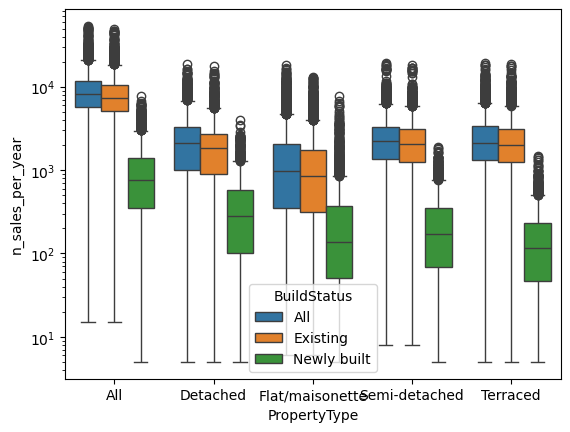

In [5]:
fig, ax = plt.subplots(1,1)
sns.boxplot(
    data=n_sales_per_year,
    x='PropertyType',
    hue='BuildStatus',
    y='n_sales_per_year',
    ax=ax
)
ax.set(yscale='log')


### Approximate yearly average from quarterly medians

In [6]:
def ave_med(df):
    if df['sales'].sum() > 50:
        prop = df['sales']/df['sales'].sum()
        out = df['median']*prop
        out_row = df.drop(columns=['median','sales','mmm','Month','Data Marking']).drop_duplicates()
        assert out_row.shape[0] == 1
        out_row = out_row.iloc[0,:]
        out_row['ave_quarterly_med'] = out.sum()
        return out_row
yearly_med_approx = merged.groupby(
    ['administrative-geography', 'PropertyType','BuildStatus','Time']
).apply(ave_med).reset_index(drop=True)

/tmp/ipykernel_20648/768536159.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(ave_med).reset_index(drop=True)


In [7]:
selector = (
    yearly_med_approx['PropertyType'] != 'All'
) & (
    yearly_med_approx['BuildStatus'] != 'All'
) & (
    yearly_med_approx['ave_quarterly_med'].notna()
)

yearly_med_approx_subtypes = yearly_med_approx.loc[selector,:]

In [8]:
yearly_med_approx_subtypes.columns

Index(['calendar-years', 'Time', 'administrative-geography', 'Geography',
       'property-type', 'PropertyType', 'build-status', 'BuildStatus',
       'ave_quarterly_med'],
      dtype='object')

In [9]:
n_obs_per_loc_type_new = yearly_med_approx_subtypes.groupby(['administrative-geography','PropertyType', 'Time'])['BuildStatus'].value_counts()
assert n_obs_per_loc_type_new.max() == 1

In [10]:
yearly_med_approx_subtypes['PropertyType'].unique()

array(['Detached', 'Flat/maisonette', 'Semi-detached', 'Terraced'],
      dtype=object)

In [11]:
yearly_med_approx_subtypes['BuildStatus'].unique()

array(['Existing', 'Newly built'], dtype=object)

In [12]:

def get_normed_trend(df):
    df_out = df.sort_values(['Time'])
    df_out = df.loc[df['ave_quarterly_med'].notna(),:]
    if (df_out.shape[0] > 1) and (df_out['Time'].min() == 2015):
        df_out['perc_increase'] = df_out['ave_quarterly_med'] / df_out['ave_quarterly_med'].iloc[0]
        return df_out

yearly_med_approx_subtypes = yearly_med_approx_subtypes.groupby(
    ['Geography','PropertyType','BuildStatus']
).apply(get_normed_trend).reset_index(drop=True)

/tmp/ipykernel_20648/2478695070.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(get_normed_trend).reset_index(drop=True)


In [13]:
yearly_med_approx_subtypes.isna().any()

calendar-years              False
Time                        False
administrative-geography    False
Geography                   False
property-type               False
PropertyType                False
build-status                False
BuildStatus                 False
ave_quarterly_med           False
perc_increase               False
dtype: bool

In [14]:
yearly_med_approx_subtypes

,calendar-years,Time,administrative-geography,Geography,property-type,PropertyType,build-status,BuildStatus,ave_quarterly_med,perc_increase
0,2015.0,2015.0,E07000223,Adur,detached,Detached,existing,Existing,355737.704918,1.000000
1,2016.0,2016.0,E07000223,Adur,detached,Detached,existing,Existing,386291.354839,1.085888
2,2017.0,2017.0,E07000223,Adur,detached,Detached,existing,Existing,414582.701062,1.165417
3,2018.0,2018.0,E07000223,Adur,detached,Detached,existing,Existing,403825.115562,1.135177
4,2019.0,2019.0,E07000223,Adur,detached,Detached,existing,Existing,417776.348228,1.174394
...,...,...,...,...,...,...,...,...,...,...
17112,2017.0,2017.0,E06000014,York,terraced,Terraced,newly-built,Newly built,263584.961538,1.132045
17113,2018.0,2018.0,E06000014,York,terraced,Terraced,newly-built,Newly built,276266.576087,1.186510
17114,2019.0,2019.0,E06000014,York,terraced,Terraced,newly-built,Newly built,297131.015957,1.276119
17115,2020.0,2020.0,E06000014,York,terraced,Terraced,newly-built,Newly built,273407.662722,1.174232


/tmp/ipykernel_20648/2658000405.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/tmp/ipykernel_20648/2658000405.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/tmp/ipykernel_20648/2658000405.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/tmp/ipykernel_20648/2658000405.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/tmp/ipykernel_20648/2658000405.py:11: UserWarning: No artists with labe

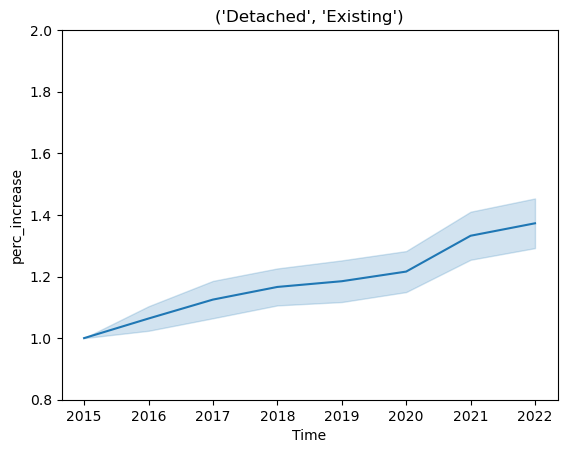

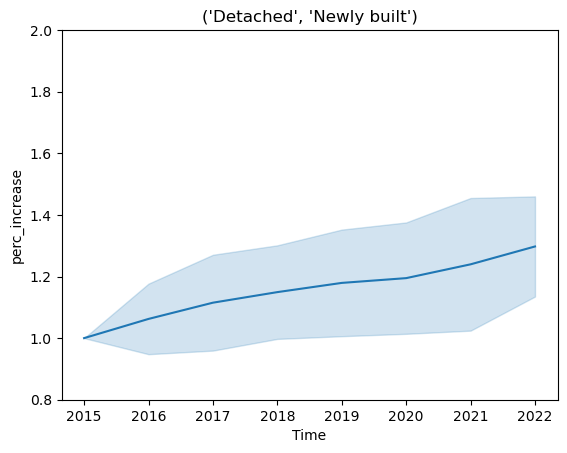

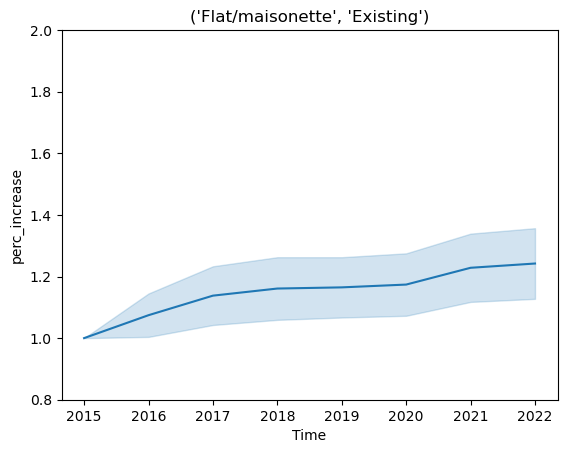

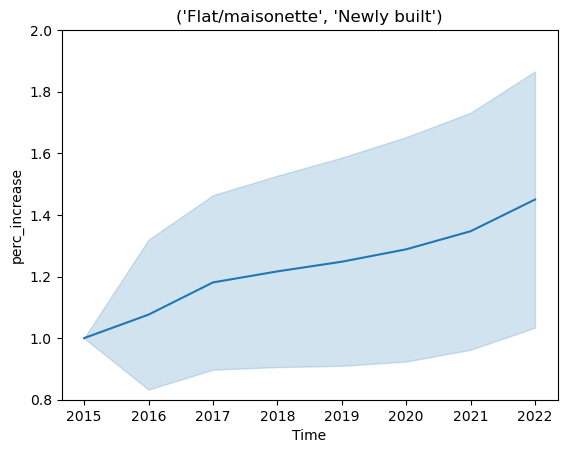

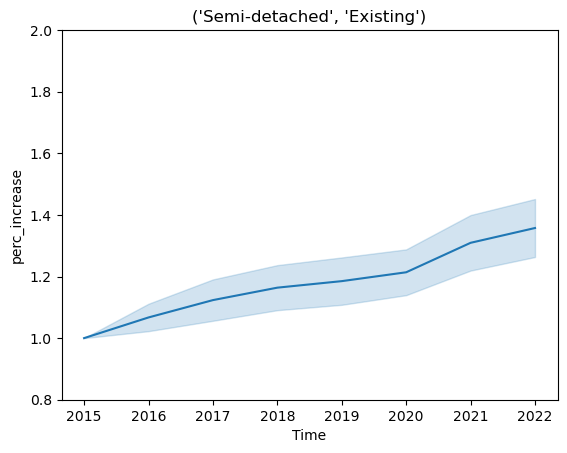

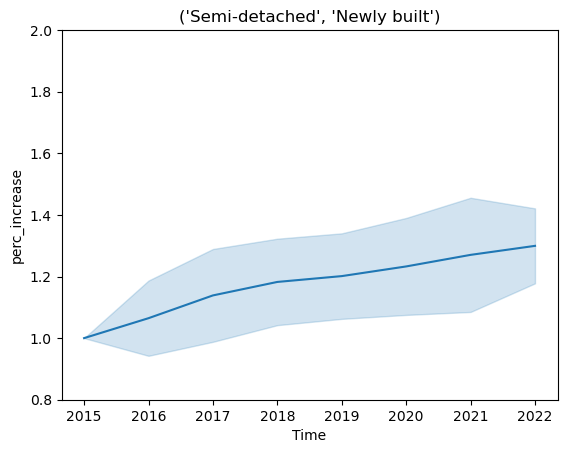

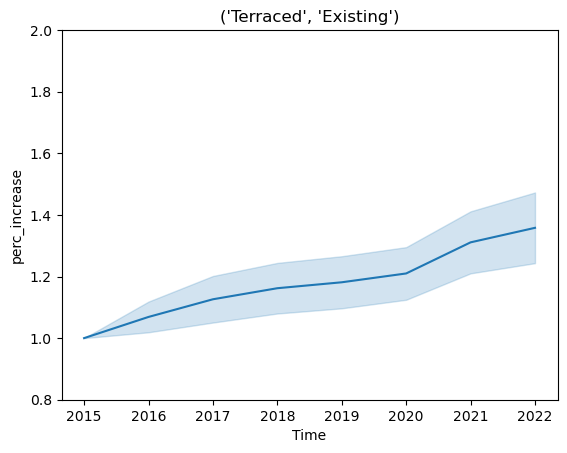

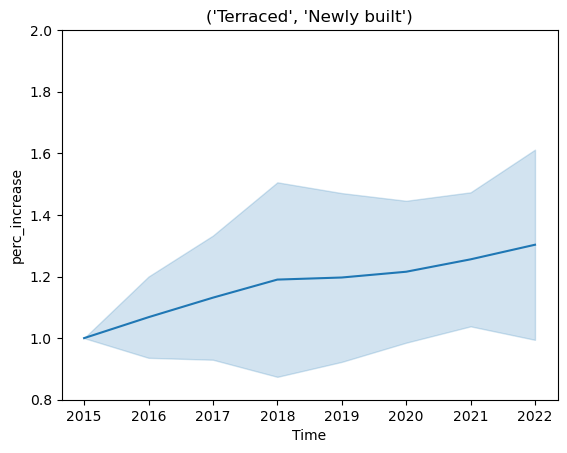

In [15]:
for grp, df in yearly_med_approx_subtypes.groupby(['PropertyType','BuildStatus']):
    fig, ax = plt.subplots(1,1)
    sns.lineplot(
        data=df,
        x='Time',
        y='perc_increase',
        errorbar='sd',
        ax=ax
    )
    ax.set(title=grp, ylim=(0.8, 2))
    ax.legend().remove()
    

In [16]:
col_local_auth_code = 'local_auth_code'
col_local_auth_name = 'local_auth_name'
col_prop_type = 'prop_type'
col_is_new_build = 'is_new_build'
col_time = 'Time'
col_perc_increase = 'perc_increase'
df_yearly_med_approx_subtypes_final = yearly_med_approx_subtypes.drop(
    columns=['property-type','build-status','ave_quarterly_med']
).rename(
    columns={
        'administrative-geography': col_local_auth_code,
        'Geography': col_local_auth_name,
        'PropertyType':col_prop_type,
        'BuildStatus':col_is_new_build
    }
)
df_yearly_med_approx_subtypes_final[col_is_new_build] = df_yearly_med_approx_subtypes_final[col_is_new_build] == 'Newly built'
df_yearly_med_approx_subtypes_final

,calendar-years,Time,local_auth_code,local_auth_name,prop_type,is_new_build,perc_increase
0,2015.0,2015.0,E07000223,Adur,Detached,False,1.000000
1,2016.0,2016.0,E07000223,Adur,Detached,False,1.085888
2,2017.0,2017.0,E07000223,Adur,Detached,False,1.165417
3,2018.0,2018.0,E07000223,Adur,Detached,False,1.135177
4,2019.0,2019.0,E07000223,Adur,Detached,False,1.174394
...,...,...,...,...,...,...,...
17112,2017.0,2017.0,E06000014,York,Terraced,True,1.132045
17113,2018.0,2018.0,E06000014,York,Terraced,True,1.186510
17114,2019.0,2019.0,E06000014,York,Terraced,True,1.276119
17115,2020.0,2020.0,E06000014,York,Terraced,True,1.174232


In [17]:
df_yearly_med_approx_subtypes_final.groupby(
    [col_local_auth_code,col_prop_type, col_is_new_build]
)[col_time].min().max()

2015.0

In [18]:
df_yearly_med_approx_subtypes_final.groupby(
    [col_local_auth_code,col_prop_type, col_is_new_build]
)[col_time].max().min()

2016.0

In [19]:
df_yearly_med_approx_subtypes_final.groupby(col_local_auth_name)[col_local_auth_code].nunique().max()

1

In [20]:
df_yearly_med_approx_subtypes_final.groupby(col_local_auth_code)[col_local_auth_name].nunique().max()

1

In [21]:
df_yearly_med_approx_subtypes_final.loc[df_yearly_med_approx_subtypes_final[col_local_auth_name] == 'Cambridge']

,calendar-years,Time,local_auth_code,local_auth_name,prop_type,is_new_build,perc_increase
2240,2015.0,2015.0,E07000008,Cambridge,Detached,False,1.000000
2241,2016.0,2016.0,E07000008,Cambridge,Detached,False,1.130506
2242,2017.0,2017.0,E07000008,Cambridge,Detached,False,1.111733
2243,2018.0,2018.0,E07000008,Cambridge,Detached,False,1.148494
2244,2019.0,2019.0,E07000008,Cambridge,Detached,False,1.145658
2245,2020.0,2020.0,E07000008,Cambridge,Detached,False,1.193172
2246,2021.0,2021.0,E07000008,Cambridge,Detached,False,1.228949
2247,2022.0,2022.0,E07000008,Cambridge,Detached,False,1.323228
2248,2015.0,2015.0,E07000008,Cambridge,Detached,True,1.000000
2249,2016.0,2016.0,E07000008,Cambridge,Detached,True,1.279917


## Geographical coordinates

In [22]:
df_coords = pd.read_csv(os.path.join(INPUT_DIR, 'LAU1_Jan_2018_FEB_in_the_UK_2022_6450079329381097976.csv'))
df_coords = df_coords.rename(columns={'lau118cd':col_local_auth_code})

In [23]:
df_coords[col_local_auth_code].isin(df_yearly_med_approx_subtypes_final[col_local_auth_code]).sum()

322

In [24]:
df_yearly_med_approx_subtypes_final[col_local_auth_code].isin(df_coords[col_local_auth_code]).mean()

0.9716071741543495

In [25]:
df_coords_final = df_coords.loc[
    df_coords[col_local_auth_code].isin(
         df_yearly_med_approx_subtypes_final[col_local_auth_code]
    ),
    [col_local_auth_code, 'long','lat']
].copy()

## N bedrooms by property type by region

In [26]:
df_n_bedroom = pd.read_csv(os.path.join(INPUT_DIR,'DC4102EW.csv'))

In [27]:
set([i.split(';')[1] for i in df_n_bedroom.columns if ';' in i])

{' Age of dependent child: Age 0 to 2',
 ' Age of dependent child: Age 10 to 11',
 ' Age of dependent child: Age 12 to 14',
 ' Age of dependent child: Age 15',
 ' Age of dependent child: Age 16',
 ' Age of dependent child: Age 17',
 ' Age of dependent child: Age 18',
 ' Age of dependent child: Age 3 to 4',
 ' Age of dependent child: Age 5 to 7',
 ' Age of dependent child: Age 8 to 9',
 ' Age of dependent child: All categories: Age of dependent child'}

In [28]:
set([i.split(';')[2] for i in df_n_bedroom.columns if ';' in i])

{' Accommodation Type: All categories: Accommodation type',
 ' Accommodation Type: Other: Flat, maisonette or apartment in a commercial building, or mobile/temporary accommodation',
 ' Accommodation Type: Other: Flat, maisonette or apartment in a purpose-built block of flats or tenement',
 ' Accommodation Type: Other: Flat, maisonette or apartment that is part of a converted or shared house (including bed-sits)',
 ' Accommodation Type: Other: Total',
 ' Accommodation Type: Whole house or bungalow: Detached',
 ' Accommodation Type: Whole house or bungalow: Semi-detached',
 ' Accommodation Type: Whole house or bungalow: Terraced (including end-terrace)',
 ' Accommodation Type: Whole house or bungalow: Total'}

In [29]:
set([i.split(';')[0] for i in df_n_bedroom.columns])

{'Bedrooms: 1 bedroom',
 'Bedrooms: 2 bedrooms',
 'Bedrooms: 3 bedrooms',
 'Bedrooms: 4 bedrooms',
 'Bedrooms: 5 or more bedrooms',
 'Bedrooms: All categories: Number of bedrooms',
 'date',
 'geography',
 'geography code'}

In [30]:
df_n_bedroom = df_n_bedroom.rename(columns={'geography code':col_local_auth_code})
assert df_n_bedroom[col_local_auth_code].value_counts().max() == 1
selector = (
    df_n_bedroom.columns.str.contains('Age of dependent child: All categories')
) & ~df_n_bedroom.columns.str.contains('Bedrooms: All categories:')
df_n_bedroom = df_n_bedroom[np.r_[[col_local_auth_code], df_n_bedroom.columns[selector]]]
str_rmv = 'Age of dependent child: All categories: Age of dependent child;'
cols = [i.replace(str_rmv, '') if str_rmv in i else i for i in df_n_bedroom.columns]
df_n_bedroom.columns = cols

In [31]:
df_n_bedroom[col_local_auth_code].isin(df_yearly_med_approx_subtypes_final[col_local_auth_code]).sum()

322

In [32]:
df_yearly_med_approx_subtypes_final[col_prop_type].unique()

array(['Detached', 'Flat/maisonette', 'Semi-detached', 'Terraced'],
      dtype=object)

In [33]:
col_n_beds = 'n_bed'
col_n_households = 'n_households'

def expand_row_prop_type_rooms(df):
    colnames = df.columns
    n_beds = [int(i.split('Bedrooms: ')[-1].split(' ')[0])  for i in colnames]
    prop_type = [i.split(';')[-2] for i in colnames]
    new_df = pd.DataFrame()
    new_df[col_n_beds] = n_beds
    new_df[col_prop_type] = prop_type
    new_df[col_n_households] = df.iloc[0,:].values
    
    return new_df
df_n_bedroom_long = df_n_bedroom.groupby(col_local_auth_code, group_keys=True)[
    [i for i in df_n_bedroom.columns if i != col_local_auth_code]
].apply(expand_row_prop_type_rooms).reset_index()

In [34]:
df_n_bedroom_long[col_prop_type].unique()

array(['  Accommodation Type: All categories: Accommodation type',
       '  Accommodation Type: Whole house or bungalow: Total',
       '  Accommodation Type: Whole house or bungalow: Detached',
       '  Accommodation Type: Whole house or bungalow: Semi-detached',
       '  Accommodation Type: Whole house or bungalow: Terraced (including end-terrace)',
       '  Accommodation Type: Other: Total',
       '  Accommodation Type: Other: Flat, maisonette or apartment in a purpose-built block of flats or tenement',
       '  Accommodation Type: Other: Flat, maisonette or apartment that is part of a converted or shared house (including bed-sits)',
       '  Accommodation Type: Other: Flat, maisonette or apartment in a commercial building, or mobile/temporary accommodation'],
      dtype=object)

In [35]:
x = '  Accommodation Type: All categories: Accommodation type'
assert df_n_bedroom_long.groupby([col_local_auth_code, col_n_beds]).apply(
    lambda df: df.loc[
        (df[col_prop_type] == '  Accommodation Type: Whole house or bungalow: Total') | 
        (df[col_prop_type] == '  Accommodation Type: Other: Total'),
        col_n_households
    ].sum() == df.loc[
        (df[col_prop_type] == x) ,
        col_n_households
    ].iloc[0],
    include_groups=True
).all()

/tmp/ipykernel_20648/2230330836.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  assert df_n_bedroom_long.groupby([col_local_auth_code, col_n_beds]).apply(


In [36]:
x = '  Accommodation Type: Whole house or bungalow: Total'
assert df_n_bedroom_long.groupby([col_local_auth_code, col_n_beds]).apply(
    lambda df: df.loc[
        (df[col_prop_type] == '  Accommodation Type: Whole house or bungalow: Detached') | 
        (df[col_prop_type] == '  Accommodation Type: Whole house or bungalow: Semi-detached') | 
        (df[col_prop_type] == '  Accommodation Type: Whole house or bungalow: Terraced (including end-terrace)'),
        col_n_households
    ].sum() == df.loc[
        (df[col_prop_type] == x) ,
        col_n_households
    ].iloc[0],
    include_groups=True
).all()

/tmp/ipykernel_20648/2002901720.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  assert df_n_bedroom_long.groupby([col_local_auth_code, col_n_beds]).apply(


In [37]:
df_n_bedroom_long_rlvnt = df_n_bedroom_long.loc[
    (df_n_bedroom_long[col_prop_type] == '  Accommodation Type: Whole house or bungalow: Detached') | 
    (df_n_bedroom_long[col_prop_type] == '  Accommodation Type: Whole house or bungalow: Semi-detached') | 
    (df_n_bedroom_long[col_prop_type] == '  Accommodation Type: Whole house or bungalow: Terraced (including end-terrace)') |
    (df_n_bedroom_long[col_prop_type] == '  Accommodation Type: Other: Total'),
    :
]

df_n_bedroom_long_rlvnt[col_prop_type] = df_n_bedroom_long_rlvnt[col_prop_type].replace(
    {
        '  Accommodation Type: Whole house or bungalow: Detached':'Detached',
        '  Accommodation Type: Whole house or bungalow: Semi-detached':'Semi-detached',
        '  Accommodation Type: Whole house or bungalow: Terraced (including end-terrace)':'Terraced',
        '  Accommodation Type: Other: Total':'Flat/maisonette',
    }

)

/tmp/ipykernel_20648/2828132926.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_n_bedroom_long_rlvnt[col_prop_type] = df_n_bedroom_long_rlvnt[col_prop_type].replace(


In [38]:
def get_n_bed_distr_by_prop_type(df):
    out = df[col_n_households]/df[col_n_households].sum()
    n_beds= df[col_n_beds].astype(str)
    n_beds[n_beds == '5'] = '>=5'
    out.index = 'frac_properties_n_beds__' + n_beds
    return out
df_frac_prop_n_beds = df_n_bedroom_long_rlvnt.groupby([col_local_auth_code, col_prop_type]).apply(
    get_n_bed_distr_by_prop_type
).reset_index(drop=False)
df_frac_prop_n_beds

/tmp/ipykernel_20648/1218889501.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_frac_prop_n_beds = df_n_bedroom_long_rlvnt.groupby([col_local_auth_code, col_prop_type]).apply(


n_bed,local_auth_code,prop_type,frac_properties_n_beds__1,frac_properties_n_beds__2,frac_properties_n_beds__3,frac_properties_n_beds__4,frac_properties_n_beds__>=5
0,E06000001,Detached,0.004247,0.043417,0.278433,0.492449,0.181454
1,E06000001,Flat/maisonette,0.127660,0.617021,0.178191,0.071809,0.005319
2,E06000001,Semi-detached,0.007286,0.130465,0.648886,0.160022,0.053341
3,E06000001,Terraced,0.003715,0.234519,0.586354,0.113713,0.061698
4,E06000002,Detached,0.005382,0.063584,0.331274,0.476978,0.122783
...,...,...,...,...,...,...,...
1387,W06000023,Terraced,0.010030,0.184058,0.635404,0.120359,0.050150
1388,W06000024,Detached,0.004550,0.045496,0.379436,0.456324,0.114195
1389,W06000024,Flat/maisonette,0.258182,0.407273,0.272727,0.040000,0.021818
1390,W06000024,Semi-detached,0.004933,0.129024,0.705088,0.131620,0.029335


In [39]:
df_frac_prop_n_beds_final = df_frac_prop_n_beds.loc[
    df_frac_prop_n_beds[col_local_auth_code].isin(
        df_yearly_med_approx_subtypes_final[col_local_auth_code]
    )
]

## Tenure type

In [40]:
df_tenure_type = pd.read_csv(os.path.join(INPUT_DIR,'DC4402EW.csv'))

In [41]:
df_tenure_type.columns

Index(['date', 'geography', 'geography code',
       'Accommodation Type: All categories: Accommodation type; Central Heating: All categories: Type of central heating in household; Tenure: All categories: Tenure; measures: Value',
       'Accommodation Type: All categories: Accommodation type; Central Heating: All categories: Type of central heating in household; Tenure: Owned or shared ownership: Total; measures: Value',
       'Accommodation Type: All categories: Accommodation type; Central Heating: All categories: Type of central heating in household; Tenure: Owned: Owned outright; measures: Value',
       'Accommodation Type: All categories: Accommodation type; Central Heating: All categories: Type of central heating in household; Tenure: Owned: Owned with a mortgage or loan or shared ownership; measures: Value',
       'Accommodation Type: All categories: Accommodation type; Central Heating: All categories: Type of central heating in household; Tenure: Social rented: Total; measur

In [42]:
df_tenure_type['date'].unique()

array([2011])

In [43]:
set([i.split(';')[1] for i in df_tenure_type.columns if ';' in i])

{' Central Heating: All categories: Type of central heating in household',
 ' Central Heating: Does have central heating',
 ' Central Heating: Does not have central heating'}

In [44]:
set([i.split(';')[0] for i in df_tenure_type.columns if ';' in i])

{'Accommodation Type: All categories: Accommodation type',
 'Accommodation Type: Other: Flat, maisonette or apartment in a commercial building, or mobile/temporary accommodation',
 'Accommodation Type: Other: Flat, maisonette or apartment in a purpose-built block of flats or tenement',
 'Accommodation Type: Other: Flat, maisonette or apartment that is part of a converted or shared house (including bed-sits)',
 'Accommodation Type: Other: Total',
 'Accommodation Type: Whole house or bungalow: Detached',
 'Accommodation Type: Whole house or bungalow: Semi-detached',
 'Accommodation Type: Whole house or bungalow: Terraced (including end-terrace)',
 'Accommodation Type: Whole house or bungalow: Total'}

In [45]:
set([i.split(';')[2] for i in df_tenure_type.columns if ';' in i])

{' Tenure: All categories: Tenure',
 ' Tenure: Owned or shared ownership: Total',
 ' Tenure: Owned: Owned outright',
 ' Tenure: Owned: Owned with a mortgage or loan or shared ownership',
 ' Tenure: Private rented or living rent free: Total',
 ' Tenure: Private rented: Other private rented or living rent free',
 ' Tenure: Private rented: Private landlord or letting agency',
 ' Tenure: Social rented: Other social rented',
 ' Tenure: Social rented: Rented from council (Local Authority)',
 ' Tenure: Social rented: Total'}

In [46]:
df_tenure_type = df_tenure_type.rename(columns={'geography code':col_local_auth_code})
assert df_tenure_type[col_local_auth_code].value_counts().max() == 1
selector = (
    df_tenure_type.columns.str.contains(' Central Heating: All categories: Type of central heating in household')
) & (
    ~df_tenure_type.columns.str.contains(' Tenure: All categories: Tenure')
) & (
    ~df_tenure_type.columns.str.contains(' Tenure: Owned or shared ownership: Total')
) & (
    ~df_tenure_type.columns.str.contains(' Tenure: Private rented or living rent free: Total')
)  & (
    ~df_tenure_type.columns.str.contains(' Tenure: Social rented: Total')
) 
df_tenure_type = df_tenure_type[np.r_[[col_local_auth_code], df_tenure_type.columns[selector]]]
str_rmv = ' Central Heating: All categories: Type of central heating in household'
cols = [i.replace(str_rmv, '') if str_rmv in i else i for i in df_tenure_type.columns]
df_tenure_type.columns = cols

In [47]:
df_tenure_type[col_local_auth_code].isin(df_yearly_med_approx_subtypes_final[col_local_auth_code]).sum()

322

In [48]:
df_yearly_med_approx_subtypes_final[col_prop_type].unique()

array(['Detached', 'Flat/maisonette', 'Semi-detached', 'Terraced'],
      dtype=object)

In [49]:
col_tenure = 'tenure'
col_prop_type = 'prop_type'
col_n_households = 'n_households'

def expand_row_prop_type_tenure(df):
    colnames = df.columns
    tenure = [i.split(';')[2].split(' Tenure: ')[-1] for i in colnames]
    prop_type = [i.split(';')[0] for i in colnames]
    new_df = pd.DataFrame()
    new_df[col_tenure] = tenure
    new_df[col_prop_type] = prop_type
    new_df[col_n_households] = df.iloc[0,:].values
    
    return new_df
df_tenure_type_long = df_tenure_type.groupby(col_local_auth_code, group_keys=True)[
    [i for i in df_tenure_type.columns if i != col_local_auth_code]
].apply(expand_row_prop_type_tenure).reset_index()

In [50]:
df_tenure_type_long[col_prop_type].unique()

array(['Accommodation Type: All categories: Accommodation type',
       'Accommodation Type: Whole house or bungalow: Total',
       'Accommodation Type: Whole house or bungalow: Detached',
       'Accommodation Type: Whole house or bungalow: Semi-detached',
       'Accommodation Type: Whole house or bungalow: Terraced (including end-terrace)',
       'Accommodation Type: Other: Total',
       'Accommodation Type: Other: Flat, maisonette or apartment in a purpose-built block of flats or tenement',
       'Accommodation Type: Other: Flat, maisonette or apartment that is part of a converted or shared house (including bed-sits)',
       'Accommodation Type: Other: Flat, maisonette or apartment in a commercial building, or mobile/temporary accommodation'],
      dtype=object)

In [51]:
x = 'Accommodation Type: All categories: Accommodation type'
assert df_tenure_type_long.groupby([col_local_auth_code, col_tenure]).apply(
    lambda df: df.loc[
        (df[col_prop_type] == 'Accommodation Type: Whole house or bungalow: Total') | 
        (df[col_prop_type] == 'Accommodation Type: Other: Total'),
        col_n_households
    ].sum() == df.loc[
        (df[col_prop_type] == x) ,
        col_n_households
    ].iloc[0],
    include_groups=True
).all()

/tmp/ipykernel_20648/918219427.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  assert df_tenure_type_long.groupby([col_local_auth_code, col_tenure]).apply(


In [52]:
x = 'Accommodation Type: Whole house or bungalow: Total'
assert df_tenure_type_long.groupby([col_local_auth_code, col_tenure]).apply(
    lambda df: df.loc[
        (df[col_prop_type] == 'Accommodation Type: Whole house or bungalow: Detached') | 
        (df[col_prop_type] == 'Accommodation Type: Whole house or bungalow: Semi-detached') | 
        (df[col_prop_type] == 'Accommodation Type: Whole house or bungalow: Terraced (including end-terrace)'),
        col_n_households
    ].sum() == df.loc[
        (df[col_prop_type] == x) ,
        col_n_households
    ].iloc[0],
    include_groups=True
).all()

/tmp/ipykernel_20648/178164966.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  assert df_tenure_type_long.groupby([col_local_auth_code, col_tenure]).apply(


In [53]:
df_tenure_type_long_rlvnt = df_tenure_type_long.loc[
    (df_tenure_type_long[col_prop_type] == 'Accommodation Type: Whole house or bungalow: Detached') | 
    (df_tenure_type_long[col_prop_type] == 'Accommodation Type: Whole house or bungalow: Semi-detached') | 
    (df_tenure_type_long[col_prop_type] == 'Accommodation Type: Whole house or bungalow: Terraced (including end-terrace)') |
    (df_tenure_type_long[col_prop_type] == 'Accommodation Type: Other: Total'),
    :
].copy()

df_tenure_type_long_rlvnt[col_prop_type] = df_tenure_type_long_rlvnt[col_prop_type].replace(
    {
        'Accommodation Type: Whole house or bungalow: Detached':'Detached',
        'Accommodation Type: Whole house or bungalow: Semi-detached':'Semi-detached',
        'Accommodation Type: Whole house or bungalow: Terraced (including end-terrace)':'Terraced',
        'Accommodation Type: Other: Total':'Flat/maisonette',
    }
)
df_tenure_type_long_rlvnt[col_tenure] = df_tenure_type_long_rlvnt[col_tenure].replace(
    {
       'Owned: Owned outright':'owned_outright',
       'Owned: Owned with a mortgage or loan or shared ownership':'owned_with_mortgage_or_shared_ownership',
       'Social rented: Rented from council (Local Authority)':'rented_from_local_auth',
       'Social rented: Other social rented':'other_social_rent',
       'Private rented: Private landlord or letting agency':'private_rent_commercial',
       'Private rented: Other private rented or living rent free':'private_rent_other',
    }
)

In [54]:
df_tenure_type_long_rlvnt['tenure'].unique()

array(['owned_outright', 'owned_with_mortgage_or_shared_ownership',
       'rented_from_local_auth', 'other_social_rent',
       'private_rent_commercial', 'private_rent_other'], dtype=object)

In [55]:
def get_tenure_distr_by_prop_type(df):
    out = df[col_n_households]/df[col_n_households].sum()
    tenure= 'tenure__' + df[col_tenure]
    out.index = tenure
    return out
df_frac_prop_tenure = df_tenure_type_long_rlvnt.groupby([col_local_auth_code, col_prop_type]).apply(
    get_tenure_distr_by_prop_type
).reset_index(drop=False)
df_frac_prop_tenure_final = df_frac_prop_tenure.loc[
    df_frac_prop_tenure[col_local_auth_code].isin(
        df_yearly_med_approx_subtypes_final[col_local_auth_code]
    )
]

/tmp/ipykernel_20648/191915807.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_frac_prop_tenure = df_tenure_type_long_rlvnt.groupby([col_local_auth_code, col_prop_type]).apply(


In [56]:
def get_tenure_distr_by_region(df):
    pivot = df.pivot(index=col_prop_type, columns=col_tenure, values=col_n_households)
    tot = pivot.sum().sum()
    out = pivot.sum()/tot
    tenure= 'tenure__' + out.index
    out.index = tenure
    return out
df_frac_region_tenure = df_tenure_type_long_rlvnt.groupby([col_local_auth_code]).apply(
    get_tenure_distr_by_region
).reset_index(drop=False)
df_frac_region_tenure_final = df_frac_region_tenure.loc[
    df_frac_region_tenure[col_local_auth_code].isin(
        df_yearly_med_approx_subtypes_final[col_local_auth_code]
    )
]

/tmp/ipykernel_20648/2901455391.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_frac_region_tenure = df_tenure_type_long_rlvnt.groupby([col_local_auth_code]).apply(


In [57]:
df_frac_region_tenure_final.loc[:,df_frac_region_tenure_final.columns.str.startswith('tenure')].describe()

tenure,tenure__other_social_rent,tenure__owned_outright,tenure__owned_with_mortgage_or_shared_ownership,tenure__private_rent_commercial,tenure__private_rent_other,tenure__rented_from_local_auth
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000
mean,0.078860,0.324934,0.341126,0.143260,0.028244,0.083576
std,0.039502,0.071062,0.052089,0.053213,0.008905,0.061340
min,0.013611,0.084541,0.136898,0.065010,0.014579,0.005139
25%,0.046369,0.285032,0.312976,0.107346,0.023093,0.030650
50%,0.074747,0.333689,0.348560,0.126164,0.026759,0.075498
75%,0.104189,0.373713,0.375956,0.161046,0.030956,0.112829
max,0.230574,0.471246,0.452844,0.375638,0.105557,0.312468


## Economic activity

In [58]:
df_econ_act = pd.read_csv(os.path.join(INPUT_DIR,'KS601UK.csv'))

In [59]:
df_econ_act.columns

Index(['date', 'geography', 'geography code',
       'Economic Activity: All usual residents aged 16 to 74; measures: Value',
       'Economic Activity: Economically active; measures: Value',
       'Economic Activity: Economically active: In employment; measures: Value',
       'Economic Activity: Economically active: Employee: Part-time; measures: Value',
       'Economic Activity: Economically active: Employee: Full-time; measures: Value',
       'Economic Activity: Economically active: Self-employed; measures: Value',
       'Economic Activity: Economically active: Unemployed; measures: Value',
       'Economic Activity: Economically active: Full-time student; measures: Value',
       'Economic Activity: Economically Inactive; measures: Value',
       'Economic Activity: Economically inactive: Retired; measures: Value',
       'Economic Activity: Economically inactive: Student (including full-time students); measures: Value',
       'Economic Activity: Economically inactive: Lookin

In [60]:
df_econ_act['date'].unique()

array([2011])

In [61]:
set([i.split(';')[0] for i in df_econ_act.columns if ';' in i])

{'Economic Activity: All usual residents aged 16 to 74',
 'Economic Activity: Economically Inactive',
 'Economic Activity: Economically active',
 'Economic Activity: Economically active: Employee: Full-time',
 'Economic Activity: Economically active: Employee: Part-time',
 'Economic Activity: Economically active: Full-time student',
 'Economic Activity: Economically active: In employment',
 'Economic Activity: Economically active: Self-employed',
 'Economic Activity: Economically active: Unemployed',
 'Economic Activity: Economically inactive: Long-term sick or disabled',
 'Economic Activity: Economically inactive: Looking after home or family',
 'Economic Activity: Economically inactive: Other',
 'Economic Activity: Economically inactive: Retired',
 'Economic Activity: Economically inactive: Student (including full-time students)',
 'Economic Activity: Long-term unemployed',
 'Economic Activity: Unemployed: Age 16 to 24',
 'Economic Activity: Unemployed: Age 50 to 74',
 'Economic Acti

In [62]:
set([i.split(';')[1] for i in df_econ_act.columns if ';' in i])

{' measures: Value'}

In [63]:
df_econ_act = df_econ_act.rename(columns={'geography code':col_local_auth_code})
str_rmv = '; measures: Value'
df_econ_act.columns = [i.replace(str_rmv,'') for i in df_econ_act.columns]

In [64]:
df_econ_act[col_local_auth_code].isin(df_yearly_med_approx_subtypes_final[col_local_auth_code]).sum()

322

In [65]:
x = 'Economic Activity: All usual residents aged 16 to 74'
selector = (
    df_econ_act.columns == 'Economic Activity: Economically active'
)|(
    df_econ_act.columns == 'Economic Activity: Economically Inactive'
)
assert (df_econ_act.loc[:, selector].sum(axis=1) == df_econ_act[x]).all()

In [66]:
x = 'Economic Activity: All usual residents aged 16 to 74'
selector = (
    df_econ_act.columns.str.startswith('Economic Activity:')
    & (df_econ_act.columns != x)
)
df_econ_act_final = df_econ_act.copy()
for col in df_econ_act.columns[selector]:
    df_econ_act_final[col] = df_econ_act_final[col]/df_econ_act_final[x]

In [67]:
selector = (
    (df_econ_act_final.columns != x)
    & (df_econ_act_final.columns != 'Economic Activity: Economically active')
    & (df_econ_act_final.columns != 'Economic Activity: Economically Inactive')
    &(df_econ_act_final.columns != 'Economic Activity: Economically active: In employment')
)
df_econ_act_final = df_econ_act_final.loc[:,selector]

In [68]:
map = {
    'Economic Activity: Economically active: Employee: Part-time':'econ_act_part_time',
    'Economic Activity: Economically active: Employee: Full-time':'econ_act_full_time',
    'Economic Activity: Economically active: Self-employed':'econ_act_self_emp',
    'Economic Activity: Economically active: Unemployed':'econ_act_unemp',
    'Economic Activity: Economically active: Full-time student':'econ_inact_ft_student',
    'Economic Activity: Economically inactive: Retired':'econ_inact_retired',
    'Economic Activity: Economically inactive: Student (including full-time students)':'econ_inact_student',
    'Economic Activity: Economically inactive: Looking after home or family':'econ_inact_family_care',
    'Economic Activity: Economically inactive: Long-term sick or disabled':'econ_inact_long_term_health',
    'Economic Activity: Economically inactive: Other':'econ_inact_other',
    'Economic Activity: Unemployed: Age 16 to 24':'econ_act_unemp_16to24',
    'Economic Activity: Unemployed: Age 50 to 74':'econ_act_unemp_50to74',
    'Economic Activity: Unemployed: Never worked':'econ_act_never_worked',
    'Economic Activity: Long-term unemployed':'econ_act_long_term_unemp'
}
df_econ_act_final = df_econ_act_final.rename(columns=map)

In [69]:
selector = (
    (df_econ_act_final.columns == col_local_auth_code) |
    df_econ_act_final.columns.str.startswith('econ_')
)
df_econ_act_final = df_econ_act_final.loc[df_econ_act_final[col_local_auth_code].isin(df_yearly_med_approx_subtypes_final[col_local_auth_code]),selector]

In [70]:
df_econ_act_final.loc[:,df_econ_act_final.columns.str.startswith('econ_')].describe()

,econ_act_part_time,econ_act_full_time,econ_act_self_emp,econ_act_unemp,econ_inact_ft_student,econ_inact_retired,econ_inact_student,econ_inact_family_care,econ_inact_long_term_health,econ_inact_other,econ_act_unemp_16to24,econ_act_unemp_50to74,econ_act_never_worked,econ_act_long_term_unemp
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000
mean,0.140138,0.387150,0.101206,0.040735,0.031552,0.146060,0.051645,0.041728,0.039771,0.020016,0.011551,0.007892,0.006058,0.015954
std,0.016435,0.040156,0.027201,0.012336,0.011345,0.035732,0.027804,0.008666,0.015939,0.006620,0.003865,0.001432,0.003476,0.005484
min,0.057079,0.264106,0.050300,0.020097,0.017381,0.047122,0.024242,0.023328,0.013482,0.011359,0.004598,0.004487,0.001147,0.006919
25%,0.135218,0.363207,0.078581,0.030589,0.024579,0.125533,0.034900,0.035898,0.026990,0.015265,0.008472,0.006912,0.003381,0.011539
50%,0.143748,0.385585,0.099826,0.038960,0.027083,0.150453,0.041457,0.040277,0.037648,0.018157,0.010951,0.007643,0.005035,0.015161
75%,0.149909,0.412718,0.119372,0.047932,0.034212,0.169962,0.057254,0.045934,0.048536,0.022499,0.014311,0.008559,0.007869,0.019364
max,0.167322,0.514508,0.174473,0.080248,0.083705,0.240553,0.218380,0.074282,0.096412,0.047122,0.023741,0.012859,0.020191,0.036740


## Ethnic group

In [71]:
df_ethn_rlgn = pd.read_csv(os.path.join(INPUT_DIR, 'LC2201EW.csv'))

In [72]:
df_ethn_rlgn.columns

Index(['date', 'geography', 'geography code',
       'Ethnic Group: All categories: Ethnic group; Religion: All categories: Religion; measures: Value',
       'Ethnic Group: All categories: Ethnic group; Religion: Christian; measures: Value',
       'Ethnic Group: All categories: Ethnic group; Religion: Buddhist; measures: Value',
       'Ethnic Group: All categories: Ethnic group; Religion: Hindu; measures: Value',
       'Ethnic Group: All categories: Ethnic group; Religion: Jewish; measures: Value',
       'Ethnic Group: All categories: Ethnic group; Religion: Muslim; measures: Value',
       'Ethnic Group: All categories: Ethnic group; Religion: Sikh; measures: Value',
       'Ethnic Group: All categories: Ethnic group; Religion: Other religion; measures: Value',
       'Ethnic Group: All categories: Ethnic group; Religion: No religion; measures: Value',
       'Ethnic Group: All categories: Ethnic group; Religion: Religion not stated; measures: Value',
       'Ethnic Group: White:

In [73]:
df_ethn_rlgn['date'].unique()

array([2011])

In [74]:
set([i.split(';')[0] for i in df_ethn_rlgn.columns if ';' in i])

{'Ethnic Group: All categories: Ethnic group',
 'Ethnic Group: Asian/Asian British',
 'Ethnic Group: Black/African/Caribbean/Black British',
 'Ethnic Group: Mixed/multiple ethnic group',
 'Ethnic Group: Other ethnic group',
 'Ethnic Group: White: English/Welsh/Scottish/Northern Irish/British',
 'Ethnic Group: White: Irish',
 'Ethnic Group: White: Other White',
 'Ethnic Group: White: Total'}

In [75]:
set([i.split(';')[1] for i in df_ethn_rlgn.columns if ';' in i])

{' Religion: All categories: Religion',
 ' Religion: Buddhist',
 ' Religion: Christian',
 ' Religion: Hindu',
 ' Religion: Jewish',
 ' Religion: Muslim',
 ' Religion: No religion',
 ' Religion: Other religion',
 ' Religion: Religion not stated',
 ' Religion: Sikh'}

In [76]:
set([i.split(';')[2] for i in df_ethn_rlgn.columns if ';' in i])

{' measures: Value'}

In [77]:
df_ethn_rlgn = df_ethn_rlgn.rename(columns={'geography code':col_local_auth_code})
str_rmv = '; measures: Value'
df_ethn_rlgn.columns = [i.replace(str_rmv,'') for i in df_ethn_rlgn.columns]

In [78]:
df_ethn_rlgn[col_local_auth_code].isin(df_yearly_med_approx_subtypes_final[col_local_auth_code]).sum()

322

In [79]:
x = 'Ethnic Group: All categories: Ethnic group; Religion: All categories: Religion'
selector = (
    df_ethn_rlgn.columns.str.startswith('Ethnic Group:')
)&(
    ~df_ethn_rlgn.columns.str.contains('All categories')
)&(
    ~df_ethn_rlgn.columns.str.contains('Total')
)
assert (df_ethn_rlgn.loc[:, selector].sum(axis=1) == df_ethn_rlgn[x]).all()

In [80]:
selector = (
    (df_ethn_rlgn.columns != x)
    & (~df_ethn_rlgn.columns.str.contains('All categories'))
    & (~df_ethn_rlgn.columns.str.contains('Total'))
)
df_ethn_rlgn = df_ethn_rlgn.loc[:,selector]

In [81]:
df_ethn_rlgn.columns

Index(['date', 'geography', 'local_auth_code',
       'Ethnic Group: White: English/Welsh/Scottish/Northern Irish/British; Religion: Christian',
       'Ethnic Group: White: English/Welsh/Scottish/Northern Irish/British; Religion: Buddhist',
       'Ethnic Group: White: English/Welsh/Scottish/Northern Irish/British; Religion: Hindu',
       'Ethnic Group: White: English/Welsh/Scottish/Northern Irish/British; Religion: Jewish',
       'Ethnic Group: White: English/Welsh/Scottish/Northern Irish/British; Religion: Muslim',
       'Ethnic Group: White: English/Welsh/Scottish/Northern Irish/British; Religion: Sikh',
       'Ethnic Group: White: English/Welsh/Scottish/Northern Irish/British; Religion: Other religion',
       'Ethnic Group: White: English/Welsh/Scottish/Northern Irish/British; Religion: No religion',
       'Ethnic Group: White: English/Welsh/Scottish/Northern Irish/British; Religion: Religion not stated',
       'Ethnic Group: White: Irish; Religion: Christian',
       'Ethn

In [82]:
map = {
    'Ethnic Group: Asian/Asian British':'ethn_Asian',
    'Ethnic Group: Black/African/Caribbean/Black British':'ethn_Black',
    'Ethnic Group: Mixed/multiple ethnic group':'ethn_Mixed',
    'Ethnic Group: Other ethnic group':'ethn_Other',
    'Ethnic Group: White: English/Welsh/Scottish/Northern Irish/British':'ethn_British',
    'Ethnic Group: White: Irish':'ethn_Irish',
    'Ethnic Group: White: Other White':'ethn_OtherWhite',

    ' Religion: Buddhist':'rlgn_Buddhist',
    ' Religion: Christian':'rlgn_Christian',
    ' Religion: Hindu':'rlgn_Hindu',
    ' Religion: Jewish': 'rlgn_Jew',
    ' Religion: Muslim':'rlgn_Muslim',
    ' Religion: No religion':'rlgn_None',
    ' Religion: Other religion':'rlgn_Other',
    ' Religion: Religion not stated':'rlgn_Missing',
    ' Religion: Sikh':'rlgn_Sikh'
}

new_cols = dict()
for i_orig in df_ethn_rlgn.columns:
    i = i_orig
    for k,v in map.items():
        i = i.replace(k,v)
    new_cols[i_orig] = i
df_ethn_rlgn_final = df_ethn_rlgn.copy()
df_ethn_rlgn_final.columns = df_ethn_rlgn_final.columns.map(new_cols)

selector = (
    (df_ethn_rlgn_final.columns == col_local_auth_code) |
    df_ethn_rlgn_final.columns.str.startswith('ethn_')
)
df_ethn_rlgn_final = df_ethn_rlgn_final.loc[df_ethn_rlgn_final[col_local_auth_code].isin(df_yearly_med_approx_subtypes_final[col_local_auth_code]),selector]

selector = (
    df_ethn_rlgn_final.columns.str.startswith('ethn_')
)
df = df_ethn_rlgn_final.loc[:, selector].div(
    df_ethn_rlgn_final.loc[:, selector].sum(axis=1),
    axis=0
)
for col in df.columns:
    df_ethn_rlgn_final[col] = df[col]

In [83]:
summary = df_ethn_rlgn_final.loc[:,df_ethn_rlgn_final.columns.str.startswith('ethn_')].describe().T.sort_values('std', ascending=False)
summary

,count,mean,std,min,25%,50%,75%,max
ethn_British;rlgn_Christian,322.0,0.543059,0.134932,0.095889,0.508659,0.575950,0.624090,0.782985
ethn_British;rlgn_None,322.0,0.232144,0.057502,0.049301,0.201390,0.236179,0.268013,0.404776
ethn_Asian;rlgn_Muslim,322.0,0.022449,0.043356,0.000204,0.001749,0.005017,0.020635,0.301536
ethn_Black;rlgn_Christian,322.0,0.016304,0.031060,0.000266,0.002098,0.004682,0.013261,0.198829
ethn_OtherWhite;rlgn_Christian,322.0,0.027123,0.024071,0.004158,0.011974,0.020005,0.031223,0.177259
...,...,...,...,...,...,...,...,...
ethn_Irish;rlgn_Muslim,322.0,0.000025,0.000046,0.000000,0.000000,0.000010,0.000025,0.000357
ethn_Irish;rlgn_Other,322.0,0.000034,0.000029,0.000000,0.000014,0.000027,0.000045,0.000180
ethn_Irish;rlgn_Buddhist,322.0,0.000024,0.000027,0.000000,0.000007,0.000017,0.000030,0.000184
ethn_Irish;rlgn_Hindu,322.0,0.000004,0.000011,0.000000,0.000000,0.000000,0.000005,0.000109


In [84]:
summary.loc[summary['max'] >= 0.05,:]

,count,mean,std,min,25%,50%,75%,max
ethn_British;rlgn_Christian,322.0,0.543059,0.134932,0.095889,0.508659,0.575950,0.624090,0.782985
ethn_British;rlgn_None,322.0,0.232144,0.057502,0.049301,0.201390,0.236179,0.268013,0.404776
ethn_Asian;rlgn_Muslim,322.0,0.022449,0.043356,0.000204,0.001749,0.005017,0.020635,0.301536
ethn_Black;rlgn_Christian,322.0,0.016304,0.031060,0.000266,0.002098,0.004682,0.013261,0.198829
ethn_OtherWhite;rlgn_Christian,322.0,0.027123,0.024071,0.004158,0.011974,0.020005,0.031223,0.177259
ethn_Asian;rlgn_Hindu,322.0,0.010991,0.023525,0.000219,0.001682,0.003472,0.010427,0.245432
ethn_Asian;rlgn_Sikh,322.0,0.004980,0.012667,0.000021,0.000398,0.001046,0.003165,0.092579
ethn_British;rlgn_Missing,322.0,0.060688,0.012254,0.013965,0.054860,0.062737,0.068911,0.087098
ethn_British;rlgn_Jew,322.0,0.003030,0.010943,0.000068,0.000384,0.000719,0.001657,0.129570
ethn_OtherWhite;rlgn_None,322.0,0.007844,0.009740,0.001001,0.002808,0.005208,0.008314,0.067119


In [85]:
df_ethn_rlgn_final_main = df_ethn_rlgn_final.loc[
    :,
    np.r_[[col_local_auth_code], summary.index[summary['max'] >= 0.05]]
]
df_ethn_rlgn_final_main

,local_auth_code,ethn_British;rlgn_Christian,ethn_British;rlgn_None,ethn_Asian;rlgn_Muslim,ethn_Black;rlgn_Christian,ethn_OtherWhite;rlgn_Christian,ethn_Asian;rlgn_Hindu,ethn_Asian;rlgn_Sikh,ethn_British;rlgn_Missing,ethn_British;rlgn_Jew,ethn_OtherWhite;rlgn_None,ethn_Other;rlgn_Muslim,ethn_OtherWhite;rlgn_Muslim
0,E06000005,0.641573,0.230628,0.006205,0.002662,0.017942,0.002880,0.002984,0.059746,0.000303,0.002615,0.001269,0.000407
1,E06000047,0.703274,0.201348,0.001732,0.001050,0.009173,0.001101,0.000994,0.056677,0.000316,0.002710,0.000988,0.000247
2,E06000001,0.683509,0.217934,0.005596,0.001206,0.006324,0.001663,0.000956,0.061894,0.000076,0.001260,0.000609,0.000304
3,E06000002,0.595180,0.206969,0.053529,0.008496,0.011733,0.004046,0.003692,0.053818,0.000188,0.002875,0.008381,0.001373
4,E06000057,0.671051,0.233906,0.002092,0.000750,0.006873,0.000968,0.001332,0.061745,0.000487,0.001914,0.000329,0.000152
...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,W06000018,0.493563,0.401424,0.000956,0.001040,0.005962,0.000900,0.000632,0.072430,0.000296,0.001689,0.000358,0.000140
344,W06000019,0.484559,0.404776,0.001260,0.000917,0.007821,0.000945,0.000530,0.079067,0.000100,0.001318,0.000788,0.000057
345,W06000020,0.539050,0.351578,0.001581,0.001416,0.005688,0.002229,0.000527,0.072742,0.000165,0.001372,0.000274,0.000099
346,W06000021,0.604076,0.276119,0.001205,0.001194,0.009757,0.001544,0.000482,0.073760,0.000624,0.003745,0.000657,0.000099


## Deprivation

In [86]:
df_deprivation = pd.read_csv(os.path.join(INPUT_DIR,'QS119EW.csv'))

In [87]:
df_deprivation.columns

Index(['date', 'geography', 'geography code', 'Rural Urban',
       'Household Deprivation: All categories: Classification of household deprivation; measures: Value',
       'Household Deprivation: Household is not deprived in any dimension; measures: Value',
       'Household Deprivation: Household is deprived in 1 dimension; measures: Value',
       'Household Deprivation: Household is deprived in 2 dimensions; measures: Value',
       'Household Deprivation: Household is deprived in 3 dimensions; measures: Value',
       'Household Deprivation: Household is deprived in 4 dimensions; measures: Value'],
      dtype='object')

In [88]:
df_deprivation['date'].unique()

array([2011])

In [89]:
df_deprivation['Rural Urban'].unique()

array(['Total'], dtype=object)

In [90]:
set([i.split(';')[0] for i in df_deprivation.columns if ';' in i])

{'Household Deprivation: All categories: Classification of household deprivation',
 'Household Deprivation: Household is deprived in 1 dimension',
 'Household Deprivation: Household is deprived in 2 dimensions',
 'Household Deprivation: Household is deprived in 3 dimensions',
 'Household Deprivation: Household is deprived in 4 dimensions',
 'Household Deprivation: Household is not deprived in any dimension'}

In [91]:
set([i.split(';')[1] for i in df_deprivation.columns if ';' in i])

{' measures: Value'}

In [92]:
df_deprivation = df_deprivation.rename(columns={'geography code':col_local_auth_code})
str_rmv = '; measures: Value'
df_deprivation.columns = [i.replace(str_rmv,'') for i in df_deprivation.columns]

In [93]:
df_deprivation[col_local_auth_code].isin(df_yearly_med_approx_subtypes_final[col_local_auth_code]).sum()

322

In [94]:
x = 'Household Deprivation: All categories: Classification of household deprivation'
selector = (
    df_deprivation.columns.str.startswith('Household Deprivation:')
)&(
    df_deprivation.columns != x
)
assert (df_deprivation.loc[:, selector].sum(axis=1) == df_deprivation[x]).all()

df_deprivation_final = df_deprivation.copy()
for col in df_deprivation.columns[selector]:
    df_deprivation_final[col] = df_deprivation_final[col]/df_deprivation_final[x]

map = dict()
for col in df_deprivation.columns[selector]:
    if 'not deprived' in col:
        map[col] = 'deprived_0_dim'
    else:
        n = col.split('deprived in ')[-1].split(' dimension')[0]
        n = int(n)
        map[col] = f'deprived_{n}_dim'
df_deprivation_final = df_deprivation_final.rename(columns=map)

In [95]:
df_deprivation_final

,date,geography,local_auth_code,Rural Urban,Household Deprivation: All categories: Classification of household deprivation,deprived_0_dim,deprived_1_dim,deprived_2_dim,deprived_3_dim,deprived_4_dim
0,2011,Darlington,E06000005,Total,46670,0.432483,0.319734,0.191858,0.051575,0.004350
1,2011,County Durham,E06000047,Total,223803,0.393140,0.307793,0.231659,0.064132,0.003275
2,2011,Hartlepool,E06000001,Total,40434,0.354924,0.317085,0.246575,0.076767,0.004650
3,2011,Middlesbrough,E06000002,Total,57203,0.344894,0.325420,0.239795,0.083719,0.006171
4,2011,Northumberland,E06000057,Total,138534,0.436362,0.323704,0.192848,0.044393,0.002692
...,...,...,...,...,...,...,...,...,...,...
343,2011,Caerphilly,W06000018,Total,74479,0.352019,0.300393,0.260194,0.082225,0.005169
344,2011,Blaenau Gwent,W06000019,Total,30416,0.297574,0.303853,0.290242,0.101854,0.006477
345,2011,Torfaen,W06000020,Total,38524,0.366603,0.320060,0.241434,0.067387,0.004517
346,2011,Monmouthshire,W06000021,Total,38233,0.461878,0.322784,0.176549,0.036173,0.002616


In [96]:
selector = (
    (df_deprivation_final.columns == col_local_auth_code) |
    df_deprivation_final.columns.str.startswith('deprived_')
)
df_deprivation_final = df_deprivation_final.loc[df_deprivation_final[col_local_auth_code].isin(df_yearly_med_approx_subtypes_final[col_local_auth_code]),selector]

In [97]:
df_deprivation_final.loc[:,df_deprivation_final.columns.str.startswith('deprived_')].describe()

,deprived_0_dim,deprived_1_dim,deprived_2_dim,deprived_3_dim,deprived_4_dim
count,322.000000,322.000000,322.000000,322.000000,322.000000
mean,0.433887,0.325505,0.188036,0.047967,0.004605
std,0.063844,0.016576,0.037353,0.019141,0.002676
min,0.249766,0.279602,0.103875,0.015235,0.000867
25%,0.388252,0.314526,0.161949,0.031865,0.002616
50%,0.431852,0.323091,0.189321,0.044381,0.004046
75%,0.480921,0.336155,0.213387,0.060542,0.005610
max,0.594245,0.404105,0.290242,0.106012,0.015392


## Approx social grade

In [98]:
df_soc_grade = pd.read_csv(os.path.join(INPUT_DIR,'QS611UK.csv'))

In [99]:
df_soc_grade.columns

Index(['date', 'geography', 'geography code',
       'Social Grade: Approximated social grade; measures: Value',
       'Social Grade: Approximated social grade AB; measures: Value',
       'Social Grade: Approximated social grade C1; measures: Value',
       'Social Grade: Approximated social grade C2; measures: Value',
       'Social Grade: Approximated social grade DE; measures: Value'],
      dtype='object')

In [100]:
df_soc_grade['date'].unique()

array([2011])

In [101]:
set([i.split(';')[0] for i in df_soc_grade.columns if ';' in i])

{'Social Grade: Approximated social grade',
 'Social Grade: Approximated social grade AB',
 'Social Grade: Approximated social grade C1',
 'Social Grade: Approximated social grade C2',
 'Social Grade: Approximated social grade DE'}

In [102]:
set([i.split(';')[1] for i in df_soc_grade.columns if ';' in i])

{' measures: Value'}

In [103]:
df_soc_grade = df_soc_grade.rename(columns={'geography code':col_local_auth_code})
str_rmv = '; measures: Value'
df_soc_grade.columns = [i.replace(str_rmv,'') for i in df_soc_grade.columns]

In [104]:
df_soc_grade[col_local_auth_code].isin(df_yearly_med_approx_subtypes_final[col_local_auth_code]).sum()

322

In [105]:
x = 'Social Grade: Approximated social grade'
selector = (
    df_soc_grade.columns.str.startswith('Social Grade')
)&(
    df_soc_grade.columns != x
)
assert (df_soc_grade.loc[:, selector].sum(axis=1) == df_soc_grade[x]).all()

df_soc_grade_final = df_soc_grade.copy()
for col in df_soc_grade.columns[selector]:
    df_soc_grade_final[col] = df_soc_grade_final[col]/df_soc_grade_final[x]

map = dict()
for col in df_soc_grade.columns[selector]:
    soc_grade = col.split('social grade ')[-1]
    map[col] = f'soc_grade_{soc_grade}'
df_soc_grade_final = df_soc_grade_final.rename(columns=map)

In [106]:
df_soc_grade_final

,date,geography,local_auth_code,Social Grade: Approximated social grade,soc_grade_AB,soc_grade_C1,soc_grade_C2,soc_grade_DE
0,2011,Darlington,E06000005,34354,0.181958,0.303283,0.219771,0.294987
1,2011,County Durham,E06000047,161327,0.162657,0.283858,0.229943,0.323542
2,2011,Hartlepool,E06000001,29791,0.127186,0.256050,0.238394,0.378369
3,2011,Middlesbrough,E06000002,42957,0.115255,0.266266,0.209698,0.408781
4,2011,Northumberland,E06000057,96661,0.194142,0.297380,0.234293,0.274185
...,...,...,...,...,...,...,...,...
401,2011,Newry and Mourne,95VV,26797,0.154084,0.222525,0.293503,0.329888
402,2011,Newtownabbey,95WW,25282,0.187920,0.331342,0.214580,0.266158
403,2011,North Down,95XX,23814,0.240615,0.371252,0.178886,0.209247
404,2011,Omagh,95YY,13940,0.137231,0.232999,0.307532,0.322238


In [107]:
selector = (
    (df_soc_grade_final.columns == col_local_auth_code) |
    df_soc_grade_final.columns.str.startswith('soc_grade_')
)
df_soc_grade_final = df_soc_grade_final.loc[df_soc_grade_final[col_local_auth_code].isin(df_yearly_med_approx_subtypes_final[col_local_auth_code]),selector]

In [108]:
df_soc_grade_final.loc[:,df_soc_grade_final.columns.str.startswith('soc_grade_')].describe()

,soc_grade_AB,soc_grade_C1,soc_grade_C2,soc_grade_DE
count,322.000000,322.000000,322.000000,322.000000
mean,0.230261,0.305768,0.216301,0.247670
std,0.079739,0.028719,0.042457,0.069794
min,0.092735,0.226782,0.049400,0.060285
25%,0.170917,0.284087,0.193398,0.194462
50%,0.216102,0.306257,0.223274,0.240848
75%,0.278898,0.326757,0.245383,0.302680
max,0.609545,0.379074,0.328178,0.431092


## Join all predictors

In [109]:
df_X = df_yearly_med_approx_subtypes_final[[col_local_auth_code, col_prop_type, col_is_new_build]].drop_duplicates()


for df in [
    df_coords_final,
    df_frac_prop_n_beds_final,
    df_frac_prop_tenure_final,
    df_frac_region_tenure_final,
    df_econ_act_final,
    df_ethn_rlgn_final_main,
    df_deprivation_final,
    df_soc_grade_final
]:
    cols_shared = [i for i in df.columns if i in df_X.columns]
    df_X = df_X.merge(
        df,
        on=cols_shared,
        how='left'
    )


df_prop_type = pd.get_dummies(df_X['prop_type'], drop_first=False)
df_prop_type = df_prop_type.drop(columns='Flat/maisonette')
df_prop_type = df_prop_type.rename(
    columns={
        'Detached':'Detached',
        'Semi-detached':'SemiD',
        'Terraced':'Terraced',
    }
)
cols_prop_type  = 'prop_type_' + df_prop_type.columns
df_prop_type.columns = cols_prop_type
df_X = df_X.join(df_prop_type, how='left')

col_traj_id = 'traj_id'
df_X.index = (
    df_X[col_local_auth_code] + 
    df_X[col_prop_type].map(
        {
            'Detached':'Detached',
            'Flat/maisonette':'Flat', 
            'Semi-detached':'Semi',
            'Terraced':'Terraced'
        }
    ) + 
    df_X[col_is_new_build].map({True:'New', False:'Existing'})
)
df_X = df_X.drop(columns=['prop_type'])

In [110]:
df_X.columns

Index(['local_auth_code', 'is_new_build', 'long', 'lat',
       'frac_properties_n_beds__1', 'frac_properties_n_beds__2',
       'frac_properties_n_beds__3', 'frac_properties_n_beds__4',
       'frac_properties_n_beds__>=5', 'tenure__owned_outright',
       'tenure__owned_with_mortgage_or_shared_ownership',
       'tenure__rented_from_local_auth', 'tenure__other_social_rent',
       'tenure__private_rent_commercial', 'tenure__private_rent_other',
       'econ_act_part_time', 'econ_act_full_time', 'econ_act_self_emp',
       'econ_act_unemp', 'econ_inact_ft_student', 'econ_inact_retired',
       'econ_inact_student', 'econ_inact_family_care',
       'econ_inact_long_term_health', 'econ_inact_other',
       'econ_act_unemp_16to24', 'econ_act_unemp_50to74',
       'econ_act_never_worked', 'econ_act_long_term_unemp',
       'ethn_British;rlgn_Christian', 'ethn_British;rlgn_None',
       'ethn_Asian;rlgn_Muslim', 'ethn_Black;rlgn_Christian',
       'ethn_OtherWhite;rlgn_Christian', 'ethn_As

## EDA

In [111]:
def get_max_time_max(df):
    df = df.sort_values(col_time)
    max_increase = df[col_perc_increase].max()
    time_max_increase = df.loc[
        df[col_perc_increase] == max_increase, col_time
    ].iloc[0]
    t_max = df[col_time].max()
    df_sub = df.loc[df[col_time] > 2015,:]
    rate = df_sub[col_perc_increase]/(df_sub[col_time] - 2015)
    rate = rate.mean()
    return pd.Series([max_increase, time_max_increase, rate, t_max], index=['max_perc_increase', 'time_max_increase', 'rate_increase', 'time_last_obs'])

df_traj_summary = df_yearly_med_approx_subtypes_final.groupby([col_local_auth_code, col_local_auth_name, col_prop_type, col_is_new_build]).apply(
    get_max_time_max 
).reset_index()

/tmp/ipykernel_20648/2255860535.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_traj_summary = df_yearly_med_approx_subtypes_final.groupby([col_local_auth_code, col_local_auth_name, col_prop_type, col_is_new_build]).apply(


In [112]:
df_EDA_traj_summary = df_traj_summary.merge(df_X, on=[i for i in df_X.columns if i in df_traj_summary.columns], how='left')
is_record_na = df_EDA_traj_summary.isna().any(axis=1)
df_EDA_traj_summary = df_EDA_traj_summary.loc[~is_record_na,:]
is_record_na.mean()

0.028657785738273815

In [113]:
df_EDA_traj_summary.columns

Index(['local_auth_code', 'local_auth_name', 'prop_type', 'is_new_build',
       'max_perc_increase', 'time_max_increase', 'rate_increase',
       'time_last_obs', 'long', 'lat', 'frac_properties_n_beds__1',
       'frac_properties_n_beds__2', 'frac_properties_n_beds__3',
       'frac_properties_n_beds__4', 'frac_properties_n_beds__>=5',
       'tenure__owned_outright',
       'tenure__owned_with_mortgage_or_shared_ownership',
       'tenure__rented_from_local_auth', 'tenure__other_social_rent',
       'tenure__private_rent_commercial', 'tenure__private_rent_other',
       'econ_act_part_time', 'econ_act_full_time', 'econ_act_self_emp',
       'econ_act_unemp', 'econ_inact_ft_student', 'econ_inact_retired',
       'econ_inact_student', 'econ_inact_family_care',
       'econ_inact_long_term_health', 'econ_inact_other',
       'econ_act_unemp_16to24', 'econ_act_unemp_50to74',
       'econ_act_never_worked', 'econ_act_long_term_unemp',
       'ethn_British;rlgn_Christian', 'ethn_British;r

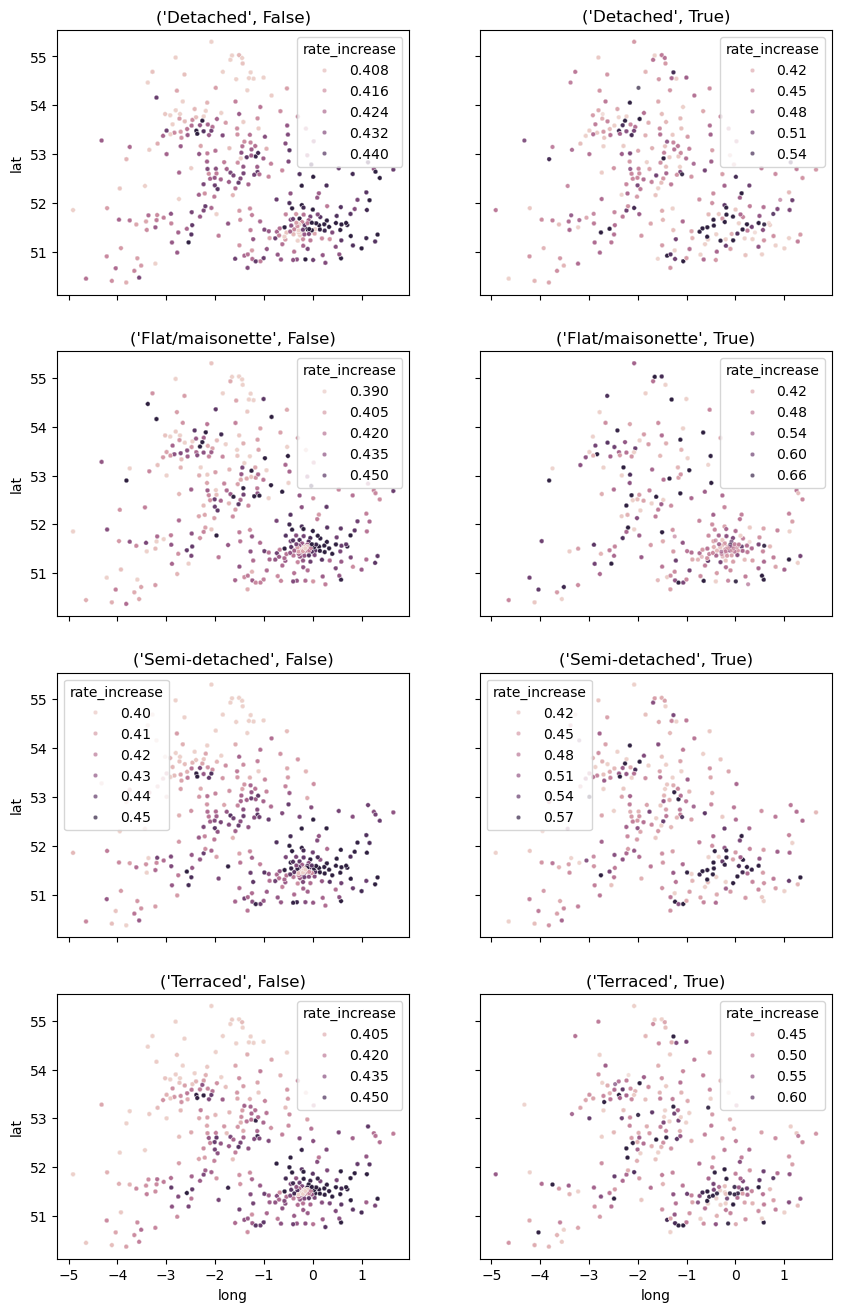

In [114]:

for y in [
    'rate_increase',
]:
    fig, axes = plt.subplots(4,2, figsize=(10, 16), sharex=True, sharey=True)

    for (grp, df), ax in zip(
        df_EDA_traj_summary.groupby([col_prop_type, col_is_new_build]),
        axes.flatten()
    ):
        df_plot = df.copy()
        cap_upper = df_plot[y].quantile(0.9)
        cap_lower = df_plot[y].quantile(0.1)
        selector = df_plot[y] > cap_upper
        df_plot.loc[selector, y] = cap_upper

        selector = df_plot[y] < cap_lower
        df_plot.loc[selector, y] = cap_lower

        sns.scatterplot(
            data=df_plot,
            x='long',
            y='lat',
            hue=y,
            ax=ax,
            s=10,
            alpha=0.7
        )
        ax.set(aspect='equal', title=grp)


In [115]:
df_X.columns

Index(['local_auth_code', 'is_new_build', 'long', 'lat',
       'frac_properties_n_beds__1', 'frac_properties_n_beds__2',
       'frac_properties_n_beds__3', 'frac_properties_n_beds__4',
       'frac_properties_n_beds__>=5', 'tenure__owned_outright',
       'tenure__owned_with_mortgage_or_shared_ownership',
       'tenure__rented_from_local_auth', 'tenure__other_social_rent',
       'tenure__private_rent_commercial', 'tenure__private_rent_other',
       'econ_act_part_time', 'econ_act_full_time', 'econ_act_self_emp',
       'econ_act_unemp', 'econ_inact_ft_student', 'econ_inact_retired',
       'econ_inact_student', 'econ_inact_family_care',
       'econ_inact_long_term_health', 'econ_inact_other',
       'econ_act_unemp_16to24', 'econ_act_unemp_50to74',
       'econ_act_never_worked', 'econ_act_long_term_unemp',
       'ethn_British;rlgn_Christian', 'ethn_British;rlgn_None',
       'ethn_Asian;rlgn_Muslim', 'ethn_Black;rlgn_Christian',
       'ethn_OtherWhite;rlgn_Christian', 'ethn_As

In [116]:
cols_x = [i for i in df_X.columns if i not in [col_local_auth_code, 'long', 'lat']]
X = df_EDA_traj_summary[cols_x]

from sklearn.manifold import TSNE as learner
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)

embedding = learner(n_components=3, method='barnes_hut')
X_transformed = pd.DataFrame(
    embedding.fit_transform(X_scaled),
    index=X.index
)
col_components = [f'Component{i}' for i in X_transformed.columns]
X_transformed.columns = col_components


In [117]:
y = 'rate_increase'
df_dim_red = X_transformed.copy()
df_dim_red[y] = np.log(df_EDA_traj_summary[y])
cap_upper = df_dim_red[y].quantile(0.9)
cap_lower = df_dim_red[y].quantile(0.1)
selector = df_dim_red[y] > cap_upper
df_dim_red.loc[selector, y] = cap_upper

selector = df_dim_red[y] < cap_lower
df_dim_red.loc[selector, y] = cap_lower
df_dim_red[y] = df_dim_red[y].astype(float)

/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


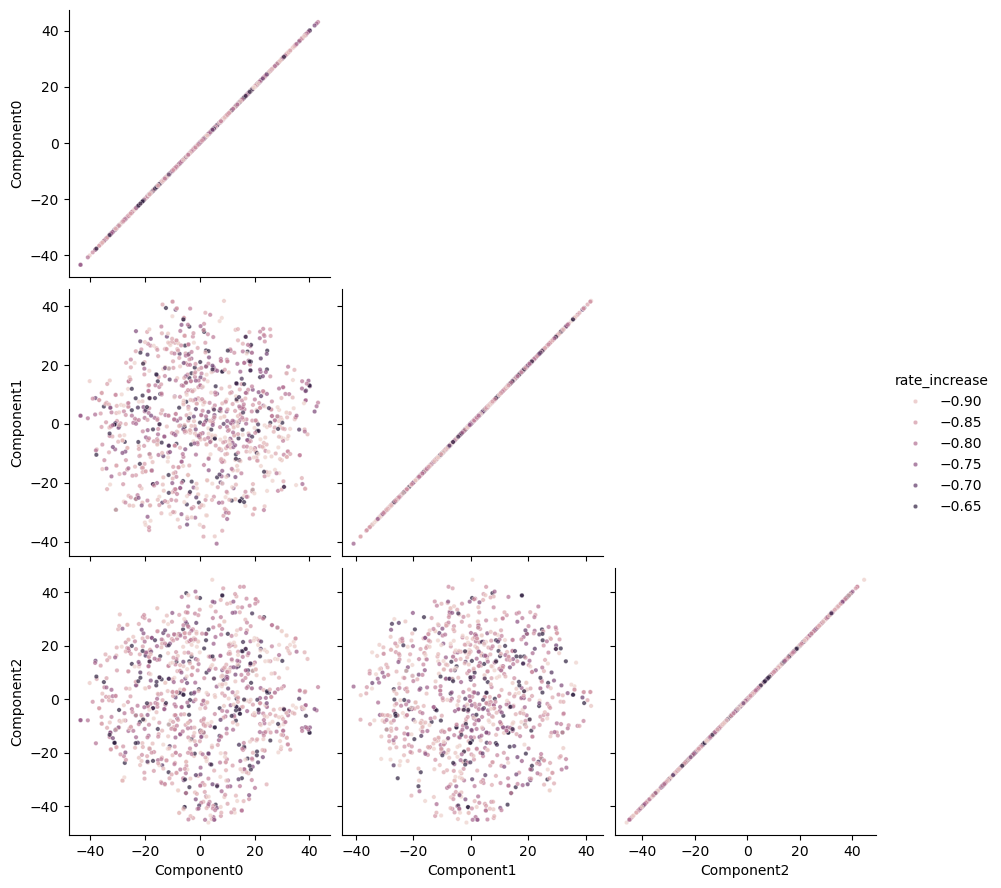

In [118]:

sns.pairplot(
    data=df_dim_red.sample(n=1000),
    hue=y,
    diag_kind=None,
    size=3,
    plot_kws={'s':10, 'alpha':0.7},
    corner=True
)

In [119]:
assert (df_X.index.nunique() == df_X.index.size)
df_X_final = df_X.drop(columns=col_local_auth_code)
df_X_final.index = df_X_final.index.rename(col_traj_id)
df_X_final.columns = 'feat__' + df_X_final.columns
cols_feat = df_X_final.columns

In [120]:
any_traj_nan_feat = df_X_final.isna().any(axis=1)
any_traj_nan_feat.sum()

64

In [121]:
df_X_final = df_X_final.loc[~any_traj_nan_feat,:]

In [122]:
cols_feat

Index(['feat__is_new_build', 'feat__long', 'feat__lat',
       'feat__frac_properties_n_beds__1', 'feat__frac_properties_n_beds__2',
       'feat__frac_properties_n_beds__3', 'feat__frac_properties_n_beds__4',
       'feat__frac_properties_n_beds__>=5', 'feat__tenure__owned_outright',
       'feat__tenure__owned_with_mortgage_or_shared_ownership',
       'feat__tenure__rented_from_local_auth',
       'feat__tenure__other_social_rent',
       'feat__tenure__private_rent_commercial',
       'feat__tenure__private_rent_other', 'feat__econ_act_part_time',
       'feat__econ_act_full_time', 'feat__econ_act_self_emp',
       'feat__econ_act_unemp', 'feat__econ_inact_ft_student',
       'feat__econ_inact_retired', 'feat__econ_inact_student',
       'feat__econ_inact_family_care', 'feat__econ_inact_long_term_health',
       'feat__econ_inact_other', 'feat__econ_act_unemp_16to24',
       'feat__econ_act_unemp_50to74', 'feat__econ_act_never_worked',
       'feat__econ_act_long_term_unemp', 'feat

In [123]:
df_X_final

,feat__is_new_build,feat__long,feat__lat,feat__frac_properties_n_beds__1,feat__frac_properties_n_beds__2,feat__frac_properties_n_beds__3,feat__frac_properties_n_beds__4,feat__frac_properties_n_beds__>=5,feat__tenure__owned_outright,feat__tenure__owned_with_mortgage_or_shared_ownership,...,feat__deprived_2_dim,feat__deprived_3_dim,feat__deprived_4_dim,feat__soc_grade_AB,feat__soc_grade_C1,feat__soc_grade_C2,feat__soc_grade_DE,feat__prop_type_Detached,feat__prop_type_SemiD,feat__prop_type_Terraced
traj_id,,,,,,,,,,,,,,,,,,,,,
E07000223DetachedExisting,False,-0.32433,50.84573,0.005065,0.056837,0.370287,0.372538,0.195273,0.578788,0.351379,...,0.203324,0.043551,0.004674,0.195039,0.336077,0.246983,0.221901,True,False,False
E07000223FlatExisting,False,-0.32433,50.84573,0.075017,0.712319,0.186511,0.019959,0.006194,0.226782,0.197541,...,0.203324,0.043551,0.004674,0.195039,0.336077,0.246983,0.221901,False,False,False
E07000223SemiExisting,False,-0.32433,50.84573,0.006395,0.114341,0.628295,0.201938,0.049031,0.416104,0.409255,...,0.203324,0.043551,0.004674,0.195039,0.336077,0.246983,0.221901,False,True,False
E07000223TerracedExisting,False,-0.32433,50.84573,0.002780,0.150681,0.687239,0.124270,0.035029,0.295233,0.474600,...,0.203324,0.043551,0.004674,0.195039,0.336077,0.246983,0.221901,False,False,True
E07000026DetachedExisting,False,-3.28096,54.68523,0.001381,0.040039,0.355030,0.413412,0.190138,0.579522,0.315119,...,0.200142,0.052072,0.002692,0.177782,0.240213,0.273077,0.308929,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E06000014FlatNew,True,-1.07375,53.96582,0.242044,0.618129,0.118129,0.015911,0.005786,0.118529,0.121374,...,0.149919,0.030209,0.002525,0.271720,0.325356,0.185182,0.217742,False,False,False
E06000014SemiExisting,False,-1.07375,53.96582,0.003880,0.129178,0.563087,0.231881,0.071974,0.390448,0.379611,...,0.149919,0.030209,0.002525,0.271720,0.325356,0.185182,0.217742,False,True,False
E06000014SemiNew,True,-1.07375,53.96582,0.003880,0.129178,0.563087,0.231881,0.071974,0.390448,0.379611,...,0.149919,0.030209,0.002525,0.271720,0.325356,0.185182,0.217742,False,True,False


In [124]:
col_perc_increase_max = col_perc_increase + '_max'

df_traj_final = df_yearly_med_approx_subtypes_final.copy()
df_traj_final[col_traj_id] = (
    df_traj_final[col_local_auth_code] + 
    df_traj_final[col_prop_type].map(
        {
            'Detached':'Detached',
            'Flat/maisonette':'Flat', 
            'Semi-detached':'Semi',
            'Terraced':'Terraced'
        }
    ) + 
    df_traj_final[col_is_new_build].map({True:'New', False:'Existing'})
)

df_traj_final = df_traj_final.sort_values(col_time).groupby(col_traj_id).apply(
    lambda df: 
    pd.DataFrame(
        {   
            col_time:df[col_time],
            col_perc_increase_max:df.expanding()[col_perc_increase].max()
        }
    )
).reset_index(level=0)
df_traj_final[col_perc_increase_max] = df_traj_final[col_perc_increase_max] - 1

/tmp/ipykernel_20648/1988491356.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_traj_final = df_traj_final.sort_values(col_time).groupby(col_traj_id).apply(


In [125]:
resol = df_traj_final.groupby(col_traj_id).apply(
    lambda df: pd.Series(np.diff(sorted(df['perc_increase_max'].unique()))).describe()
)


/tmp/ipykernel_20648/2505853665.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resol = df_traj_final.groupby(col_traj_id).apply(


In [126]:
resol.describe()

,count,mean,std,min,25%,50%,75%,max
count,2361.000000,2312.000000,2169.000000,2312.000000,2312.000000,2312.000000,2312.000000,2312.000000
mean,4.611605,0.090113,0.055506,0.040863,0.061734,0.083510,0.111576,0.155055
std,1.995423,0.101002,0.061747,0.089551,0.093097,0.102039,0.114577,0.139332
min,0.000000,0.001538,0.000071,0.000015,0.001312,0.001538,0.001538,0.001538
25%,3.000000,0.050938,0.029966,0.008891,0.026671,0.042474,0.063096,0.094329
50%,5.000000,0.064318,0.040180,0.020221,0.039502,0.058505,0.082945,0.122136
75%,6.000000,0.089548,0.056252,0.038728,0.062261,0.085940,0.114893,0.160739
max,7.000000,1.912213,1.076460,1.912213,1.912213,1.912213,1.912213,2.338358


<Axes: xlabel='perc_increase_max', ylabel='Proportion'>

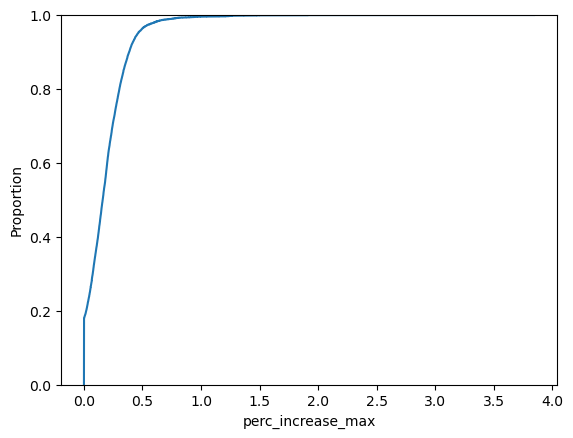

In [127]:
sns.ecdfplot(
    df_traj_final['perc_increase_max']
)

In [128]:
df_traj_final['perc_increase_max'].quantile(np.linspace(0, 1, 11))

0.0    0.000000
0.1    0.000000
0.2    0.019681
0.3    0.074965
0.4    0.120077
0.5    0.160092
0.6    0.198510
0.7    0.244063
0.8    0.302886
0.9    0.386142
1.0    3.851239
Name: perc_increase_max, dtype: float64

### Write out data tables

In [129]:
df_yearly_med_approx_subtypes_final.to_csv(os.path.join(OUTPUT_DIR,'df_yearly_med_approx_subtypes_final.csv'))
df_X.to_csv(os.path.join(OUTPUT_DIR,'df_X.csv'))

In [130]:
df_traj_final.head()

,traj_id,Time,perc_increase_max
6575,E06000001DetachedExisting,2015.0,0.000000
6576,E06000001DetachedExisting,2016.0,0.000580
6577,E06000001DetachedExisting,2017.0,0.000580
6578,E06000001DetachedExisting,2018.0,0.008855
6579,E06000001DetachedExisting,2019.0,0.035069


In [131]:
df_state_history_sampled_max = df_traj_final.copy()
df_state_history_sampled_max = df_state_history_sampled_max.rename(
    columns={
        col_time:'t',
        col_perc_increase_max:'g_max_by_time'
    }
)
df_state_history_sampled_max['t'] = df_state_history_sampled_max['t'] - 2015
df_state_history_sampled_max = df_state_history_sampled_max.loc[
    df_state_history_sampled_max[col_traj_id].isin(df_X_final.index),:
]

<Axes: xlabel='t', ylabel='Proportion'>

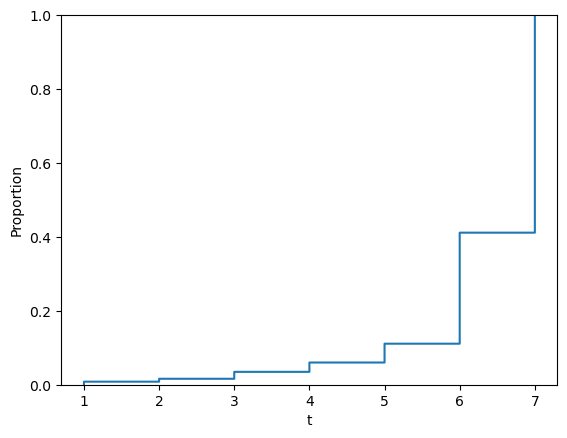

In [132]:
sns.ecdfplot(df_state_history_sampled_max.groupby(col_traj_id)['t'].max())

In [133]:
df_features = df_X_final.copy()
df_features = df_features.reset_index()

In [134]:
assert df_features.isna().any().any() == False
assert df_state_history_sampled_max.isna().any().any() == False

In [135]:
df_features.to_csv(os.path.join(OUTPUT_DIR,'df_features.csv'))
df_state_history_sampled_max.to_csv(os.path.join(OUTPUT_DIR,'df_state_history_sampled_max.csv'))